# 🎩 实战练手: RDD, IV & Granger - 因果推断进阶三剑客

> **目标**: 通过模拟数据，0-1 手写代码体验三种进阶因果推断方法。
> **场景**: 
> 1. **RDD**: 奖学金对未来收入的影响 (断点回归)
> 2. **IV**: 教育对收入的影响 (工具变量)
> 3. **Granger**: 广告投放与销量的先后关系 (时间序列)

---

In [2]:
# 0. 常用包导入
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.iv import IV2SLS # 需要 pip install linearmodels
from statsmodels.tsa.stattools import grangercausalitytests
import warnings

%matplotlib inline

np.random.seed(42)

In [ ]:
# 常量定义 (Constants Configuration)

# 1. RDD 参数 setup
RDD_N = 1000              # 样本量
RDD_SCORE_MEAN = 600      # 分数均值
RDD_SCORE_STD = 50        # 分数标准差
RDD_CUTOFF = 600          # 奖学金分数线
RDD_INCOME_BASE = 30000   # 基础收入
RDD_ABILITY_COEF = 50     # 能力(分数)对收入的系数
RDD_TREATMENT_EFFECT = 5000 # 奖学金真实效应
RDD_NOISE_STD = 2000      # 噪音标准差

# 2. IV 参数 setup
IV_N = 1000               # 样本量
IV_ABILITY_MEAN = 100     # 智商均值
IV_ABILITY_STD = 15       # 智商标准差
IV_DISTANCE_MEAN = 5      # 距离均值
IV_DISTANCE_STD = 2       # 距离标准差
IV_EDU_BASE = 10          # 教育年限基数
IV_EDU_ABILITY_COEF = 0.1 # 智商对教育的系数
IV_EDU_DISTANCE_COEF = 0.5# 距离对教育的系数 (负相关)
IV_EDU_NOISE_STD = 1      # 教育噪音
IV_INCOME_BASE = 20000    # 收入基数
IV_INCOME_EDU_COEF = 1000 # 教育真实回报 (Target)
IV_INCOME_ABILITY_COEF = 200 # 智商对收入的系数 (Confounder)
IV_INCOME_NOISE_STD = 3000   # 收入噪音

# 3. Granger 参数 setup
TS_DAYS = 100             # 时间跨度
TS_AD_MEAN = 100          # 广告费均值
TS_AD_STD = 20            # 广告费标准差
TS_SALES_AD_COEF = 0.5    # 广告对销量的系数
TS_SALES_NOISE_STD = 15   # 销量噪音



## 1. RDD (断点回归) - 奖学金案例 🎓

### 1.1 场景模拟
*   **规则**: 考分 (Score) >= 600 分的学生获得 **奖学金 (Scholarship)**。
*   **假设**: 奖学金能让学生更自信，未来收入 (Income) 增加 5000 元。
*   **逻辑**: 在 599 分和 601 分的学生，能力几乎没区别，唯一的区别是奖学金。断点处的跳跃 = 因果效应。

In [3]:
# 1. 数据生成
score = np.random.normal(RDD_SCORE_MEAN, RDD_SCORE_STD, RDD_N)
scholarship = (score >= RDD_CUTOFF).astype(int)

# 收入 = 基础收入 + 能力加成 + 奖学金效应 + 噪音
income = RDD_INCOME_BASE + RDD_ABILITY_COEF * score + RDD_TREATMENT_EFFECT * scholarship + np.random.normal(0, RDD_NOISE_STD, RDD_N)

df_rdd = pd.DataFrame({'score': score, 'scholarship': scholarship, 'income': income})
df_rdd.head()

,score,scholarship,income
0,624.835708,1,69040.496256
1,593.086785,0,61503.606613
2,632.384427,1,66738.482085
3,676.151493,1,67513.701086
4,588.292331,0,60811.063190


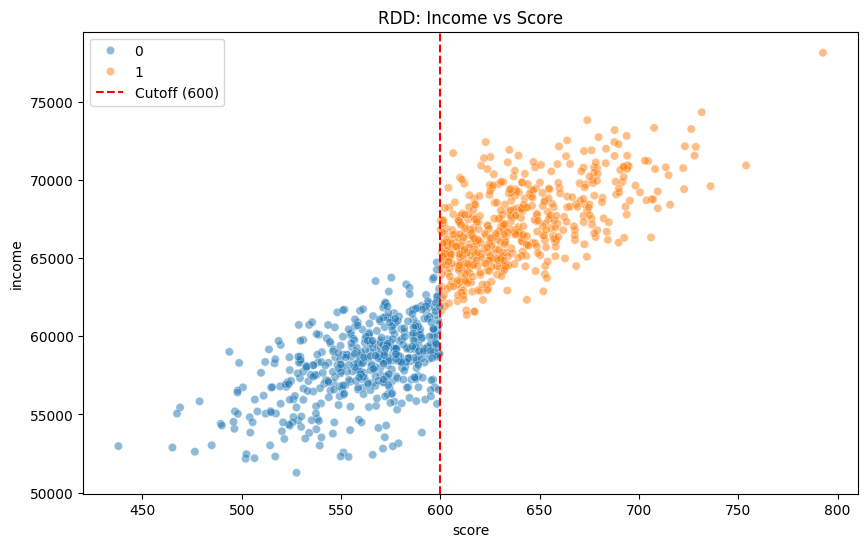

In [4]:
# 2. 可视化断点 (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_rdd, x='score', y='income', hue='scholarship', alpha=0.5)
plt.axvline(x=RDD_CUTOFF, color='red', linestyle='--', label=f'Cutoff ({RDD_CUTOFF})')
plt.title("RDD: Income vs Score")
plt.legend()
plt.show()

In [5]:
# 3. 建模 (RDD Model)
# 关键步骤: Center the running variable (让 score=0 对应 600分)
df_rdd['score_centered'] = df_rdd['score'] - RDD_CUTOFF

# 模型: Income ~ Score + Scholarship + Score*Scholarship
# 允许断点左右斜率不同
model_rdd = smf.ols("income ~ score_centered * scholarship", data=df_rdd).fit()

# scholarship 的系数就是 LATE (局部因果效应)
print(model_rdd.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     1775.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:39:42   Log-Likelihood:                -9015.6
No. Observations:                1000   AIC:                         1.804e+04
Df Residuals:                     996   BIC:                         1.806e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [6]:
df_rdd.head()

,score,scholarship,income,score_centered
0,624.835708,1,69040.496256,24.835708
1,593.086785,0,61503.606613,-6.913215
2,632.384427,1,66738.482085,32.384427
3,676.151493,1,67513.701086,76.151493
4,588.292331,0,60811.063190,-11.707669


---

## 2. IV (工具变量) - 教育回报案例 📚

### 2.1 场景模拟
*   **问题**: 多读一年书 (Education)，收入 (Income) 增加多少？
*   **混淆**: 智商 (Ability)。聪明人读得书多，赚得也多。直接回归会高估教育的回报。
*   **IV**: **距离图书馆的距离 (Distance)**。离得近读得书多，但不直接影响智商或收入。

In [7]:
# 1. 数据生成
ability = np.random.normal(IV_ABILITY_MEAN, IV_ABILITY_STD, IV_N) # 智商
distance = np.random.normal(IV_DISTANCE_MEAN, IV_DISTANCE_STD, IV_N)   # 距离 (IV)

# 教育年限: 受智商(Confounder)和距离(IV)影响
education = IV_EDU_BASE + IV_EDU_ABILITY_COEF * ability - IV_EDU_DISTANCE_COEF * distance + np.random.normal(0, IV_EDU_NOISE_STD, IV_N)

# 收入: 受教育和智商影响，不受距离直接影响
income = IV_INCOME_BASE + IV_INCOME_EDU_COEF * education + IV_INCOME_ABILITY_COEF * ability + np.random.normal(0, IV_INCOME_NOISE_STD, IV_N)

df_iv = pd.DataFrame({'education': education, 'income': income, 'ability': ability, 'distance': distance})

In [8]:
# 2. Naive OLS (错误的回归)
# 忽略智商混淆，直接回归
model_naive = smf.ols("income ~ education", data=df_iv).fit()
print(f"Naive Estimate: {model_naive.params['education']:.2f} (Bias! 真实值是{IV_INCOME_EDU_COEF})")

Naive Estimate: 1988.47 (Bias! 真实值是1000)


In [9]:
# 3. 2SLS (两阶段最小二乘法)
# 第一阶段: 用 distance 预测 education
# 第二阶段: 用 预测的education 预测 income

# 忽略 linearmodels 的 RuntimeWarning
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    iv_model = IV2SLS.from_formula(
        'income ~ 1 + [education ~ distance]', 
        data=df_iv
    ).fit()

    print(iv_model)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                 income   R-squared:                      0.3599
Estimator:                    IV-2SLS   Adj. R-squared:                 0.3593
No. Observations:                1000   F-statistic:                    32.599
Date:                Tue, Feb 17 2026   P-value (F-stat)                0.0000
Time:                        15:41:56   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept   4.295e+04     2524.9     17.010     0.0000     3.8e+04    4.79e+04
education      824.27     144.37     5.7096     0.00

./Library/Python/3.9/lib/python/site-packages/linearmodels/iv/covariance.py:277: RuntimeWarning: divide by zero encountered in matmul
  self.eps = y - x @ params
./Library/Python/3.9/lib/python/site-packages/linearmodels/iv/covariance.py:277: RuntimeWarning: overflow encountered in matmul
  self.eps = y - x @ params
./Library/Python/3.9/lib/python/site-packages/linearmodels/iv/covariance.py:277: RuntimeWarning: invalid value encountered in matmul
  self.eps = y - x @ params
./Library/Python/3.9/lib/python/site-packages/linearmodels/iv/model.py:408: RuntimeWarning: divide by zero encountered in matmul
  return self._y - self._x @ params
./Library/Python/3.9/lib/python/site-packages/linearmodels/iv/model.py:408: RuntimeWarning: overflow encountered in matmul
  return self._y - self._x @ params
./Library/Python/3.9/lib/python/site-packages/linearmodels/iv/model.py:408: RuntimeWarning: invalid value encountered in matmul
  return self._y - self._x @ params
./Library/Python/3.9/lib/python/s

---

## 3. Granger Causality (格兰杰因果) - 广告案例 📺

### 3.1 场景模拟
*   **问题**: 是广告 (Ad) 带来了销量 (Sales)，还是销量好才有钱投广告？
*   **逻辑**: 如果昨天的广告能预测今天的销量，且昨天的销量不能预测今天的广告，则广告 -> 销量。

<Axes: title={'center': 'Ad Spend vs Sales'}>

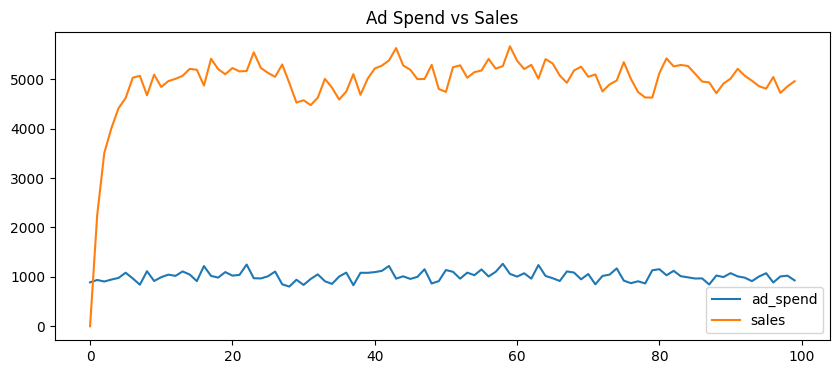

In [10]:
# 1. 数据准备 (广告 vs 销量)
ad_spend = np.random.normal(TS_AD_MEAN, TS_AD_STD, TS_DAYS)
# 销量受广告影响
sales = TS_SALES_AD_COEF * ad_spend + np.random.normal(0, TS_SALES_NOISE_STD, TS_DAYS)

df_granger = pd.DataFrame({'ad_spend': ad_spend, 'sales': sales})

plt.figure(figsize=(10, 4))
sns.lineplot(data=df_granger[['ad_spend', 'sales']])
plt.title('Ad Spend vs Sales')
plt.show()

In [11]:
# 2. 格兰杰检验
# 检验1: Ad -> Sales ? (我们期望 P < 0.05)
print(">>> Test 1: Ad Spend -> Sales")
grangercausalitytests(df_ts[['sales', 'ad_spend']], maxlag=3)

# 检验2: Sales -> Ad ? (我们期望 P > 0.05)
print("\n>>> Test 2: Sales -> Ad Spend")
grangercausalitytests(df_ts[['ad_spend', 'sales']], maxlag=3)

>>> Test 1: Ad Spend -> Sales

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1663.3481, p=0.0000  , df_denom=96, df_num=1
ssr based chi2 test:   chi2=1715.3277, p=0.0000  , df=1
likelihood ratio test: chi2=287.9267, p=0.0000  , df=1
parameter F test:         F=1663.3481, p=0.0000  , df_denom=96, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=844.9863, p=0.0000  , df_denom=93, df_num=2
ssr based chi2 test:   chi2=1780.8313, p=0.0000  , df=2
likelihood ratio test: chi2=289.4369, p=0.0000  , df=2
parameter F test:         F=844.9863, p=0.0000  , df_denom=93, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=544.7685, p=0.0000  , df_denom=90, df_num=3
ssr based chi2 test:   chi2=1761.4180, p=0.0000  , df=3
likelihood ratio test: chi2=286.4187, p=0.0000  , df=3
parameter F test:         F=544.7685, p=0.0000  , df_denom=90, df_num=3

>>> Test 2: Sales -> Ad Spend

Granger Causality
number of lags 

{np.int64(1): ({'ssr_ftest': (np.float64(1.7660664152825423),
    np.float64(0.1870196119957054),
    np.float64(96.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(1.8212559907601218),
    np.float64(0.17716384545066988),
    np.int64(1)),
   'lrtest': (np.float64(1.8047062634352642),
    np.float64(0.17914457031854616),
    np.int64(1)),
   'params_ftest': (np.float64(1.7660664152801933),
    np.float64(0.1870196119959967),
    np.float64(96.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.4774970196229442),
    np.float64(0.23351485202480868),
    np.float64(93.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(3.113864686517173),
    np.float64(0.21078168629264477),
    np.int64(2)),
   'lrtest': (np.float64(3.0654180770713992),
    np.float64(0.21594985769757602),
    np.int64(2)),
   'params_ftest': (np.float64(1.4774970196228947),
    np.float64(0.23351485202481984),
    np.float64(93.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
     